# Non-Convex Circle with V-Notch Dataset

A circle with a sharp V-shaped indentation (notch pointing inward), making the boundary non-convex.

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from lime.lime_tabular import LimeTabularExplainer
import warnings

np.random.seed(42)

CENTER = np.array([0.5, 0.5])
R_BASE = 0.4           # base circle radius
NOTCH_ANGLE = np.pi/2  # notch at the top (90°)
NOTCH_WIDTH = 0.37     # angular half-width of the notch (radians)
NOTCH_DEPTH = 0.4      # how deep the V cuts inward
MARGIN = 0.01

def boundary_radius(theta):
    """Radius as a function of angle. Dips inward with a V-notch."""
    # angular distance from the notch center, wrapped to [-pi, pi]
    d = np.abs(np.arctan2(np.sin(theta - NOTCH_ANGLE), np.cos(theta - NOTCH_ANGLE)))
    r = np.where(
        d < NOTCH_WIDTH,
        R_BASE - NOTCH_DEPTH * (1 - d / NOTCH_WIDTH),  # linear V dip
        R_BASE,
    )
    return r

def is_inside(x, y):
    dx, dy = x - CENTER[0], y - CENTER[1]
    r = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    return r < boundary_radius(theta)

n_samples = 50000
raw_x = np.random.uniform(0, 1, n_samples)
raw_y = np.random.uniform(0, 1, n_samples)

labels = np.full(n_samples, np.nan)
for i in range(n_samples):
    dx, dy = raw_x[i] - CENTER[0], raw_y[i] - CENTER[1]
    r = np.sqrt(dx**2 + dy**2)
    theta = np.arctan2(dy, dx)
    br = boundary_radius(theta)
    if r < br - MARGIN:
        labels[i] = 1.0    # inside shape
    elif r > br + MARGIN:
        labels[i] = -1.0   # outside shape

valid = ~np.isnan(labels)
labels_v = labels[valid]
inside_idx = np.where(labels_v == 1.0)[0]
outside_idx = np.where(labels_v == -1.0)[0]
n_min = min(len(inside_idx), len(outside_idx), 1500)

keep_local = np.concatenate([inside_idx[:n_min], outside_idx[:n_min]])
np.random.shuffle(keep_local)

X = np.column_stack([raw_x[np.where(valid)[0][keep_local]],
                     raw_y[np.where(valid)[0][keep_local]]])
y = labels_v[keep_local]

print(f"Dataset: {X.shape[0]} points  |  Inside (+1): {int((y==1).sum())}  |  Outside (-1): {int((y==-1).sum())}")

Dataset: 3000 points  |  Inside (+1): 1500  |  Outside (-1): 1500


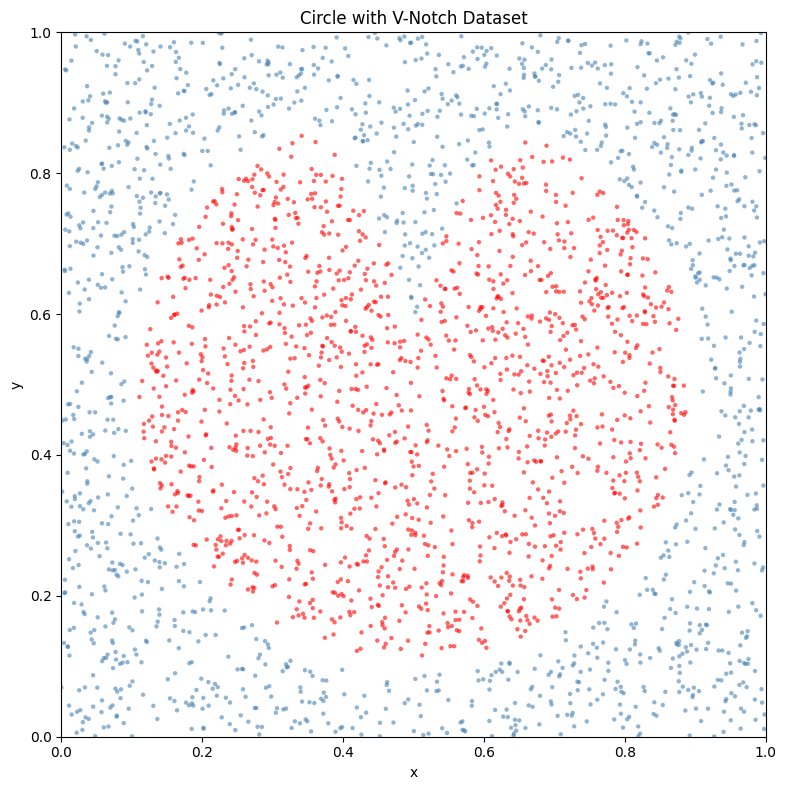

In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
colors = ['red' if label == 1 else 'steelblue' for label in y]
ax.scatter(X[:, 0], X[:, 1], c=colors, s=10, alpha=0.6, edgecolors='none')
ax.set_title('Circle with V-Notch Dataset')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## Train SVM-RBF and run LIME on the two test points

In [25]:
warnings.filterwarnings('ignore')

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

clf = SVC(kernel='rbf', C=100, gamma='scale', probability=True)
clf.fit(X_train, y_train)
print(f"SVM-RBF accuracy: {accuracy_score(y_test, clf.predict(X_test)):.2%}")

def find_boundary_point(theta_arm, r_lo=0.0, r_hi=0.5, tol=1e-4):
    """Binary search along a radial line for the SVM's decision boundary."""
    for _ in range(200):
        r_mid = (r_lo + r_hi) / 2
        pt = CENTER + r_mid * np.array([np.cos(theta_arm), np.sin(theta_arm)])
        p_inside = clf.predict_proba(pt.reshape(1, -1))[0, 1]
        if p_inside > 0.5:
            r_lo = r_mid
        else:
            r_hi = r_mid
        if r_hi - r_lo < tol:
            break
    return CENTER + r_mid * np.array([np.cos(theta_arm), np.sin(theta_arm)])

arm_offset = 0.1

test_pt1 = find_boundary_point(NOTCH_ANGLE + arm_offset) - (0, 0.02) # left arm
test_pt2 = find_boundary_point(NOTCH_ANGLE - arm_offset) - (0, 0.02) # right arm
# test_pt3 = find_boundary_point(NOTCH_ANGLE - arm_offset) - (0.2, 0.3) # right arm


p1 = clf.predict_proba(test_pt1.reshape(1, -1))[0]
p2 = clf.predict_proba(test_pt2.reshape(1, -1))[0]
print(f"Test pt 1: ({test_pt1[0]:.4f}, {test_pt1[1]:.4f})  P(inside)={p1[1]:.3f}")
print(f"Test pt 2: ({test_pt2[0]:.4f}, {test_pt2[1]:.4f})  P(inside)={p2[1]:.3f}")
print(f"Distance:  {np.linalg.norm(test_pt1 - test_pt2):.4f}")

SVM-RBF accuracy: 99.67%
Test pt 1: (0.4832, 0.6469)  P(inside)=0.681
Test pt 2: (0.5168, 0.6471)  P(inside)=0.682
Distance:  0.0335


Distance between points: 0.034
Test pt 1 (inside):  weights=(-0.0228, -0.0833)  angle=-105.3°
Test pt 2 (outside): weights=(+0.0363, -0.1052)  angle=-71.0°
Angle difference: 34.4°


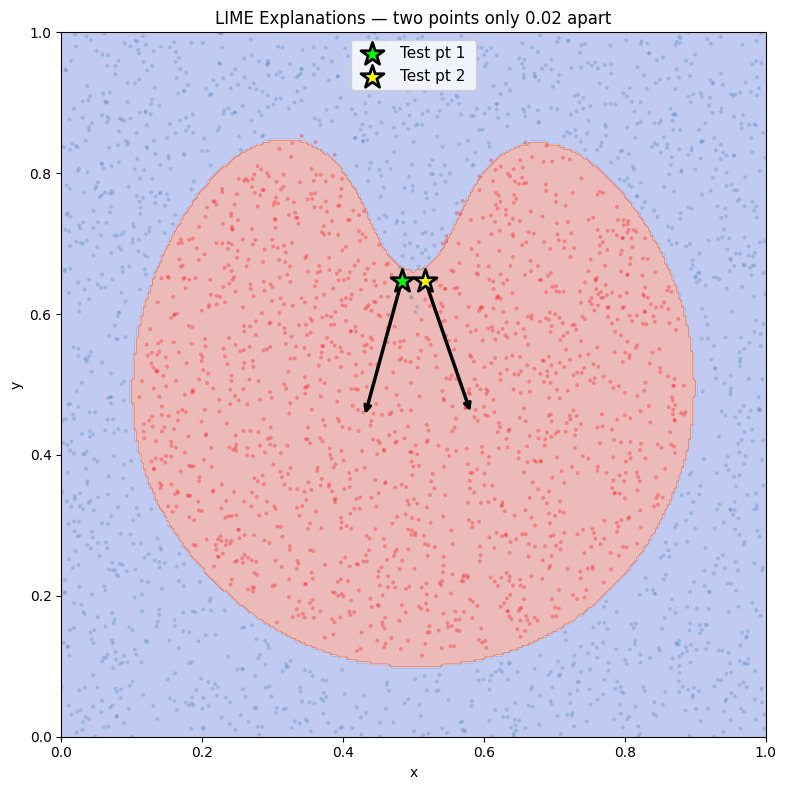

In [26]:
# def step_kernel(d, kernel_width):
#     """Hard step: full weight inside kernel_width, zero outside."""
#     return (d <= kernel_width).astype(float)

RADIUS = 0.1  # controls locality — change this, not the arrow size

explainer = LimeTabularExplainer(
    X_train, feature_names=['x', 'y'],
    class_names=['outside (-1)', 'inside (+1)'],
    mode='classification', random_state=0,
    # kernel=step_kernel,
    kernel_width=RADIUS,
    sample_around_instance=True,
    discretize_continuous=False,
)

exp1 = explainer.explain_instance(test_pt1, clf.predict_proba, num_features=2, num_samples=500)
exp2 = explainer.explain_instance(test_pt2, clf.predict_proba, num_features=2, num_samples=500)
# exp3 = explainer.explain_instance(test_pt3, clf.predict_proba, num_features=2, num_samples=500)

vec1 = np.array([dict(exp1.local_exp[1]).get(i, 0) for i in range(2)])
vec2 = np.array([dict(exp2.local_exp[1]).get(i, 0) for i in range(2)])

angle1 = np.degrees(np.arctan2(vec1[1], vec1[0]))
angle2 = np.degrees(np.arctan2(vec2[1], vec2[0]))

print(f"Distance between points: {np.linalg.norm(test_pt1 - test_pt2):.3f}")
print(f"Test pt 1 (inside):  weights=({vec1[0]:+.4f}, {vec1[1]:+.4f})  angle={angle1:.1f}°")
print(f"Test pt 2 (outside): weights=({vec2[0]:+.4f}, {vec2[1]:+.4f})  angle={angle2:.1f}°")
print(f"Angle difference: {abs(angle1 - angle2):.1f}°")

xx, yy = np.meshgrid(np.linspace(0, 1, 300), np.linspace(0, 1, 300))
grid = np.column_stack([xx.ravel(), yy.ravel()])
Z = clf.predict(grid).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(8, 8))
ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.35)
ax.scatter(X[:, 0], X[:, 1], c=['red' if l == 1 else 'steelblue' for l in y],
           s=8, alpha=0.3, edgecolors='none')

for pt, vec, color, label in [
    (test_pt1, vec1, 'lime',   'Test pt 1 '),
    (test_pt2, vec2, 'yellow', 'Test pt 2 '),
    # (test_pt3, vec2, 'purple', 'Test pt 3 '),
    
]:
    ax.scatter(*pt, c=color, s=300, marker='*', edgecolors='k', linewidths=2, zorder=10, label=label)
    scale = 0.20 / (np.linalg.norm(vec) + 1e-8)
    ax.annotate('', xy=(pt[0]+vec[0]*scale, pt[1]+vec[1]*scale), xytext=pt,
                arrowprops=dict(arrowstyle='->', lw=2.5, color='k', ))

ax.set_title(f'LIME Explanations — two points only 0.02 apart')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()